In [58]:
%load_ext autoreload
%autoreload 2

import materialdatabase as mdb
from hybridmag.utils import comsol_interface as comsol

from utils import material_processing as materials
from utils import infinite_cylinder as ic
from utils.physics import *
from utils.maths import *
from meta import paths
from meta.plot_settings import colors

import matplotlib
from matplotlib import pyplot as plt

path2simulations = paths.simulation_data
path2plots = paths.grafics

# -------------------------
# Helpful definitions
# -------------------------
cm = 1 / 2.54

# -------------------------
# Matplotlib settings
# -------------------------
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.sans-serif": ["Bitstream Vera Sans", "DejaVu Sans", "Helvetica", "Arial", "sans-serif"],
    "font.size": 10.0,
    "text.latex.preamble": r"\usepackage{upgreek}\usepackage{siunitx}",
    "mathtext.fontset": "custom",
    "mathtext.rm": "Bitstream Vera Serif",
    "mathtext.it": "Bitstream Vera Serif:italic",
    "mathtext.bf": "Bitstream Vera Serif:bold"
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Material Definition

In [59]:
# -------------------------
# Material (linear)
# -------------------------
mu_real, mu_imag = 2124, 354
mu_lin = mu_0 * (mu_real - 1j * mu_imag)
print(f"Permeability: {np.round(abs(mu_lin) / mu_0, decimals=2)}")
print(f"mag. loss angle: {np.round(np.rad2deg(np.arctan(mu_lin.imag / mu_lin.real)), decimals=2)}")

eps_real, eps_imag = 79201, 33595
eps_lin = epsilon_0 * (eps_real - 1j * eps_imag)
print(f"Permittivity: {np.round(abs(eps_lin) / epsilon_0, decimals=2)}")
print(f"el. loss angle: {np.round(np.rad2deg(np.arctan(eps_lin.imag / eps_lin.real)), decimals=2)}")

Permeability: 2153.3
mag. loss angle: -9.46
Permittivity: 86031.52
el. loss angle: -22.99


### IC vs. 2D FEM

In [60]:
# -------------------------
# Geometry definition
# Relevant geometric parameters of a PQ4040 core
# -------------------------
R = 0.0149/2  # radius
H_w = 0.0298 # height of winding window

#### Linear

MRE (IC): 0.3 %
MRE (static): -60.13 %


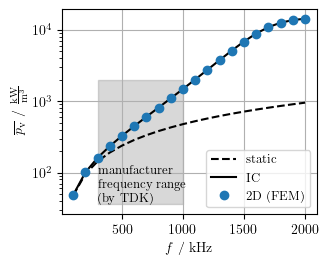

In [61]:
# -------------------------
# 2D FEM losses
# -------------------------
df_2D_FEM = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("IC_model/results_linear.txt"),
    header=["f", "PF_dim", "b_mean", "p_v", "p_mag", "p_el"]
)

# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
pv_IC, pv_static = [], []
for index, row in df_2D_FEM.iterrows():
    f = row["f"] * 1000
    b_mean = row["b_mean"] / 1000

    # -------------------------
    # IC model
    # -------------------------
    pv_IC.append(ic.pv_from_b_mean__linear(R=R, f=f, b_mean=b_mean, eps=eps_lin, mu=mu_lin))

    # -------------------------
    # Static model
    # -------------------------
    pv_static.append(ic.pv_from_b_mean__linear(R=R, f=f, b_mean=b_mean, eps=epsilon_0, mu=mu_lin))


# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(figsize=(8.6 * cm, 7 * cm))

ax.semilogy(df_2D_FEM["f"], np.array(pv_static) / 1000, "--", label=r"static", color="black")
ax.semilogy(df_2D_FEM["f"], np.array(pv_IC) / 1000, "-", label=r"IC", color="black")
ax.semilogy(df_2D_FEM["f"], df_2D_FEM["p_v"] / 1000, "o", label=f"2D (FEM)")

# Error metrics
rel_err_IC = (np.array(pv_IC) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
rel_err_static = (np.array(pv_static) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
print(f"MRE (IC): {np.round(np.mean(rel_err_IC)*100, decimals=2)} %")
print(f"MRE (static): {np.round(np.mean(rel_err_static)*100, decimals=2)} %")

# -------------------------
# Add shaded region (manufacturer frequency range)
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000
y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)
ax.text(
    f_min_kHz,
    y_min,
    "manufacturer\nfrequency range\n(by TDK)",
    ha='left', va='bottom',
    fontsize=9, color='black'
)

# -------------------------
# Final plot settings
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

ax.legend(ncols=1, loc="lower right", fontsize=9)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.png"))
plt.show()

#### Non-linear material data

In [62]:
# -------------------------
# Material (nonlinear)
# -------------------------
T_c = 60

# init a material database instance
mdb_data = mdb.Data()

complex_permeability = mdb_data.get_complex_permeability(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB,
                                                         pv_fit_function=mdb.FitFunction.enhancedSteinmetz,
                                                         probe_codes=["R16x9.6x6.3"])

complex_permittivity = mdb_data.get_complex_permittivity(material=mdb.Material.N49,
                                                         data_source=mdb.DataSource.LEA_MTB)

c:\users\tpiepe\repositories\materialdatabase\materialdatabase\processing\utils\empirical.py:136: RuntimeWarning: invalid value encountered in log
  return np.log(enhanced_steinmetz_qT(fTb, alpha, beta, k_b, k_f, k_alpha2, c_0, c_1, c_2))


MRE (IC): -0.09 %
MRE (static): -47.54 %


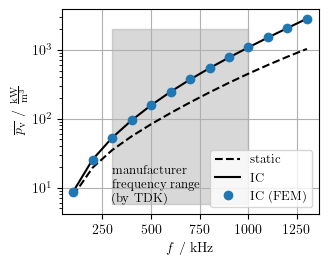

In [63]:
df_2D_FEM = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("IC_model/results_non_linear.txt"),
    header=["f", "PF_dim", "b_mean", "p_v", "p_mag", "p_el"]
)

# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
b_common = np.linspace(0, 0.2, 50)
pv_IC, pv_static = [], []
for index, row in df_2D_FEM.iterrows():
    f = row["f"] * 1000
    b_mean = row["b_mean"] / 1000

    # -------------------------
    # Material fit at temperature and frequency
    # -------------------------
    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - j * eps_imag)

    # -------------------------
    # IC model
    # -------------------------
    pv_IC.append(ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=eps, mu_of_h=mu_h))

    # -------------------------
    # Static model
    # -------------------------
    pv_static.append(ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=epsilon_0, mu_of_h=mu_h))

# -------------------------
# Plots
# -------------------------
fig, ax = plt.subplots(figsize=(8.6 * cm, 7 * cm))

ax.semilogy(df_2D_FEM["f"], np.array(pv_static) / 1000, "--", label=r"static", color="black")
ax.semilogy(df_2D_FEM["f"], np.array(pv_IC) / 1000, "-", label=r"IC", color="black")
ax.semilogy(df_2D_FEM["f"], df_2D_FEM["p_v"] / 1000, "o", label=f"IC (FEM)")

# Error metrics
rel_err_IC = (np.array(pv_IC) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
rel_err_static = (np.array(pv_static) - df_2D_FEM["p_v"]) / df_2D_FEM["p_v"]
print(f"MRE (IC): {np.round(np.mean(rel_err_IC)*100, decimals=2)} %")
print(f"MRE (static): {np.round(np.mean(rel_err_static)*100, decimals=2)} %")


# -------------------------
# Add shaded region (manufacturer frequency range)
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000
y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)
ax.text(
    f_min_kHz,
    y_min,
    "manufacturer\nfrequency range\n(by TDK)",
    ha='left', va='bottom',
    fontsize=9, color='black'
)

# -------------------------
# Final plot settings
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

ax.legend(ncols=1, loc="lower right", fontsize=9)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_linear.png"))
plt.show()

### 3D FEM simulations vs. IC model

Computation:

In [80]:
# -------------------------
# Load FEM results and add the analytically computed solutions
# -------------------------
# auxiliary information - must equal settings in the FEM simulations:
b_mean = 50e-3
d_g = np.array([0, 1.8, 1.8, 1.8]) * 1e-3
no_gaps = ["0", "1", "2", "3"]

df_3D_FEM_pv_center = comsol.read_df_from_comsol_table(
    link2file=path2simulations.joinpath("PQ_model/FEM_vs_IC/core_losses.txt"),
    header=["f"] + no_gaps
)

# use the center leg volume (incorporating the air gap lengths) to calculate the average loss density in the center leg
V_center = (H_w-d_g) * np.pi * R**2
df_3D_FEM_pv_center[no_gaps] = df_3D_FEM_pv_center[no_gaps].div(V_center, axis=1)


# -------------------------
# Loop over frequencies according to FEM results
# -------------------------
for index, row in df_3D_FEM_pv_center.iterrows():
    f = row["f"]

    # -------------------------
    # Material fit at temperature and frequency
    # -------------------------
    # Permeability:
    mu_real, mu_imag = complex_permeability.fit_real_and_imaginary_part_at_f_and_T(f_op=f,
                                                                                   T_op=T_c,
                                                                                   b_vals=np.linspace(0, 0.2, 50))
    # an interpolation in terms of the magnetic field h is needed:
    mu_h = materials.mu_h_from_mu_b((mu_real - j * mu_imag) * mu_0, b_common)

    # Permittivity:
    eps_real, eps_imag = complex_permittivity.fit_real_and_imaginary_part_at_f_and_T(f=f, T=T_c)
    eps = epsilon_0 * (eps_real - j * eps_imag)

    # -------------------------
    # IC model
    # -------------------------
    df_3D_FEM_pv_center.loc[index, "pv_IC"]  = ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=eps, mu_of_h=mu_h)

    # -------------------------
    # Static model
    # -------------------------
    df_3D_FEM_pv_center.loc[index, "pv_static"] = ic.pv_from_b_mean__non_linear(b_mean_selected=b_mean, R=R, f=f, eps=epsilon_0, mu_of_h=mu_h)


Plotting:

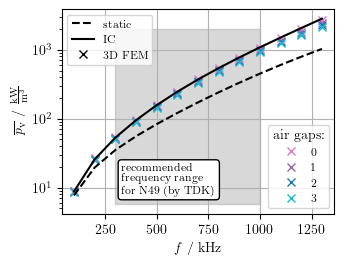

In [81]:
fig, ax = plt.subplots(figsize=(9*cm, 7*cm))
comsol_color = '0.8'

for index, col in enumerate(no_gaps):
    ax.semilogy(df_3D_FEM_pv_center["f"]/1000, df_3D_FEM_pv_center[col]/1000, "x", label=f"{col}", color=colors[index])
ax.semilogy(df_3D_FEM_pv_center["f"]/1000, df_3D_FEM_pv_center["pv_IC"]/1000, "-", color="black")
ax.semilogy(df_3D_FEM_pv_center["f"]/1000, df_3D_FEM_pv_center["pv_static"]/1000, "--", color="black")


# -------------------------
# Add shaded region
# -------------------------
f_min_kHz = 300
f_max_kHz = 1000

y_min, y_max = ax.get_ylim()
y_max = 2000
ax.fill_betweenx([y_min, y_max], f_min_kHz, f_max_kHz, color='gray', alpha=0.3)

ax.text(
    f_min_kHz * 1.1,
    y_min * 1.3,
    "recommended\nfrequency range\nfor N49 (by TDK)",
    ha='left', va='bottom',
    fontsize=8, color='black',
    bbox=dict(facecolor='white', edgecolor='k', boxstyle='round,pad=0.3')
)


# -------------------------
# Final plot touches
# -------------------------
ax.set_xlabel(r"$f$ / kHz")
ax.set_ylabel(r"$\overline{p_\mathrm{v}}$ / $\frac{\mathrm{kW}}{\mathrm{m}^3}$")

line1 = matplotlib.lines.Line2D([0], [0], label=r"static", color='k', linestyle="--")
line2 = matplotlib.lines.Line2D([0], [0], label=r"IC", color='k')
line3 = matplotlib.lines.Line2D([0], [0], label=r"3D FEM", color='k', marker="x", linestyle="")
legend1 = ax.legend(handles=[line1, line2, line3], ncol=1, loc="upper left", fontsize=8)

ax.legend(ncols=1, loc="lower right", title="air gaps:", fontsize=8)
plt.gca().add_artist(legend1)

ax.grid()
fig.align_labels()
plt.tight_layout()

plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_nonlinear.pdf"))
plt.savefig(path2plots.joinpath("FEM_vs_IC_losses_nonlinear.png"))
plt.show()